In [3]:
!pip install pandas
import pandas as pd

# Load the students dataset from CSV
df = pd.read_csv("students.csv")

# Task 1 — Data Exploration
# Display the first 5 rows to understand data structure
print("First 5 rows:")
print(df.head())
print()

# Show the dimensions (rows, columns) of the dataset
print("Shape:", df.shape)
print()

# Display data types of each column
print("Column dtypes:")
print(df.dtypes)
print()

# Get statistical summary (count, mean, std, min, quartiles, max)
print("Numeric summary:")
print(df.describe())
print()

# Count the number of students who passed vs failed
print("Pass / fail counts:")
print(df["passed"].value_counts())
print()

# Calculate average scores for each subject
subject_cols = ["math", "science", "english", "history", "pe"]

# Compare average scores between passing and failing students
print("Average scores — passed students:")
print(df[df["passed"] == 1][subject_cols].mean())
print()
print("Average scores — failed students:")
print(df[df["passed"] == 0][subject_cols].mean())
print()

# Find the student with the highest overall average score
df["_overall_avg"] = df[subject_cols].mean(axis=1)
top = df.loc[df["_overall_avg"].idxmax()]
print("Highest overall average:", top["name"], f"({top['_overall_avg']:.2f})")
df.drop(columns="_overall_avg", inplace=True)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl (12.3 MB)
Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached notebook-7.5.5-py3-none-any.whl.metadata (10 kB)
  Using cached ju


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Matplotlib is building the font cache; this may take a moment.


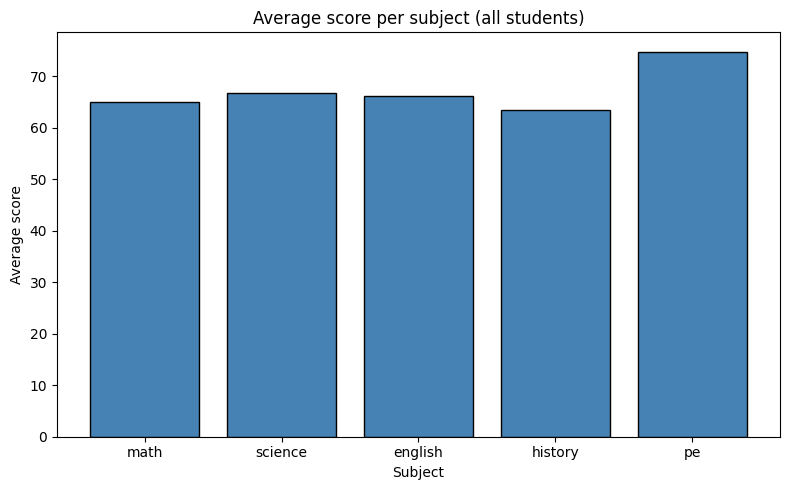

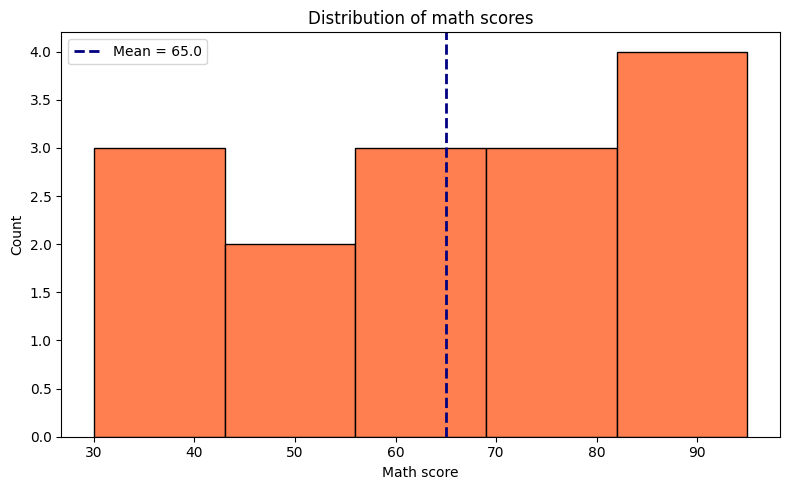

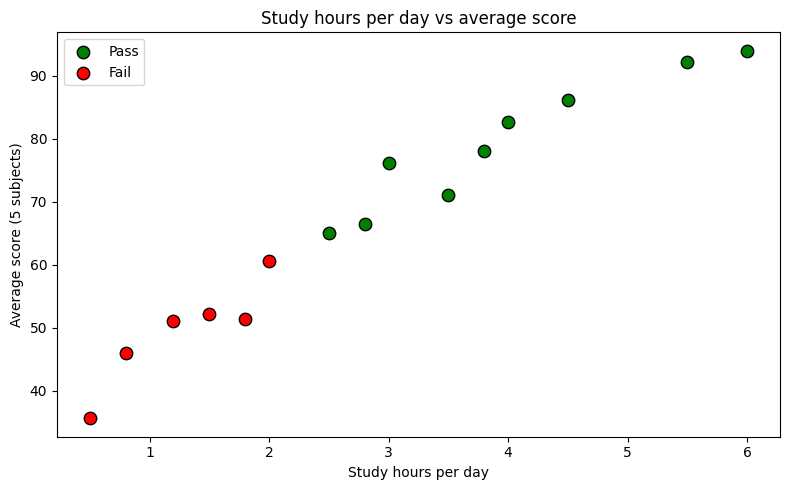

C:\Users\Purnima Srivastava\AppData\Local\Temp\ipykernel_22192\2091895441.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


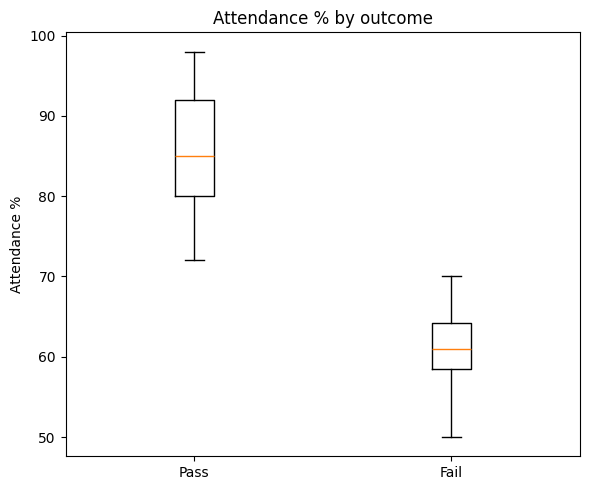

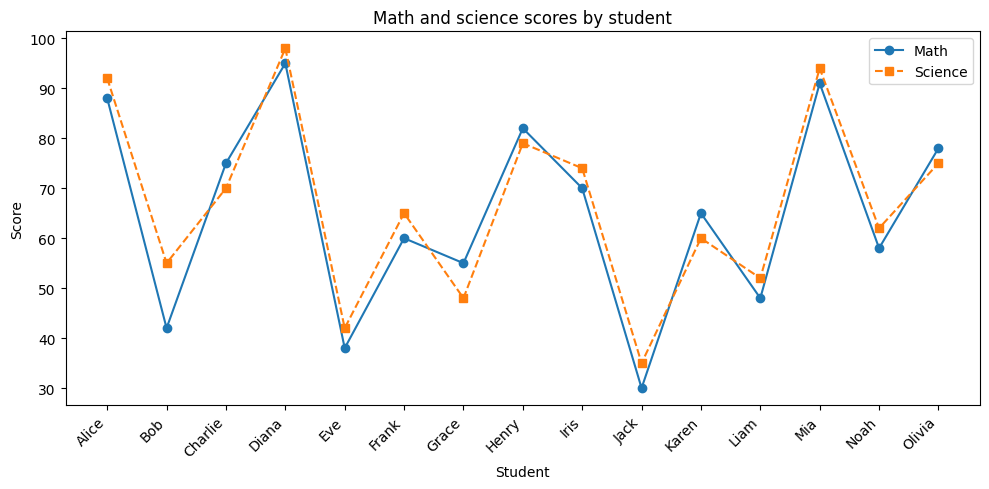

In [5]:
!pip install matplotlib numpy seaborn scikit-learn jupyter
import matplotlib.pyplot as plt
import numpy as np

# Define subject columns and calculate average score across all subjects
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)

# 1) Bar chart — average score per subject (all students combined)
plt.figure(figsize=(8, 5))
subject_means = df[subject_cols].mean()
plt.bar(subject_cols, subject_means.values, color="steelblue", edgecolor="black")
plt.title("Average score per subject (all students)")
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.tight_layout()
plt.savefig("plot1_bar.png", dpi=150)
plt.show()

# 2) Histogram — distribution of math scores with mean line
# Shows the frequency distribution across 5 bins with a dashed line marking the mean
plt.figure(figsize=(8, 5))
math_mean = df["math"].mean()
plt.hist(df["math"], bins=5, color="coral", edgecolor="black")
plt.axvline(math_mean, color="navy", linestyle="--", linewidth=2, label=f"Mean = {math_mean:.1f}")
plt.title("Distribution of math scores")
plt.xlabel("Math score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_hist.png", dpi=150)
plt.show()

# 3) Scatter plot — study hours per day vs average score, colored by pass/fail outcome
# Green points = passing students, Red points = failing students
plt.figure(figsize=(8, 5))
pass_df = df[df["passed"] == 1]
fail_df = df[df["passed"] == 0]
plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], c="green", label="Pass", s=80, edgecolors="black")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], c="red", label="Fail", s=80, edgecolors="black")
plt.title("Study hours per day vs average score")
plt.xlabel("Study hours per day")
plt.ylabel("Average score (5 subjects)")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png", dpi=150)
plt.show()

# 4) Box plot — attendance percentage by pass/fail outcome
# Shows quartiles and outliers for each group
plt.figure(figsize=(6, 5))
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])
plt.title("Attendance % by outcome")
plt.ylabel("Attendance %")
plt.tight_layout()
plt.savefig("plot4_box.png", dpi=150)
plt.show()

# 5) Line plot — math and science scores for each student
# Line markers: circle for math, square for science
plt.figure(figsize=(10, 5))
x = np.arange(len(df))
plt.plot(x, df["math"], marker="o", linestyle="-", label="Math")
plt.plot(x, df["science"], marker="s", linestyle="--", label="Science")
plt.xticks(x, df["name"], rotation=45, ha="right")
plt.title("Math and science scores by student")
plt.xlabel("Student")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png", dpi=150)
plt.show()


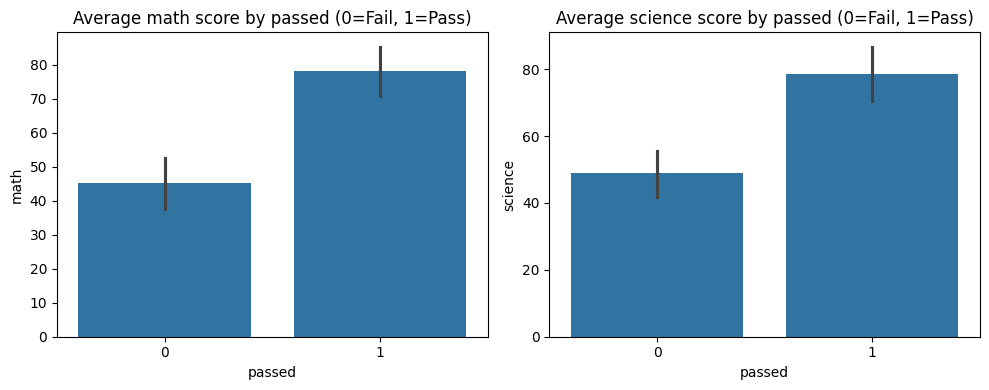

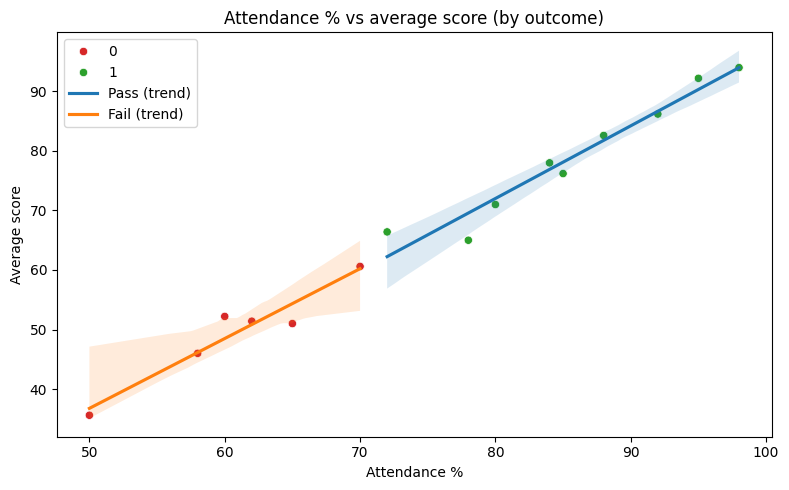

In [6]:
import seaborn as sns

# Task 3 — Seaborn: Statistical visualization library for cleaner plots

# Create side-by-side bar plots showing average math and science scores by pass/fail outcome
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df, x="passed", y="math", ax=ax1)
ax1.set_title("Average math score by passed (0=Fail, 1=Pass)")
ax1.set_xlabel("passed")
ax1.set_ylabel("math")
sns.barplot(data=df, x="passed", y="science", ax=ax2)
ax2.set_title("Average science score by passed (0=Fail, 1=Pass)")
ax2.set_xlabel("passed")
ax2.set_ylabel("science")
plt.tight_layout()
plt.savefig("seaborn_bar_passed.png", dpi=150)
plt.show()

# Scatter plot with overlaid regression line for each outcome group
# This shows the relationship between attendance and average score, segmented by pass/fail
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="attendance_pct", y="avg_score", hue="passed", palette={0: "tab:red", 1: "tab:green"})
sns.regplot(data=df[df["passed"] == 1], x="attendance_pct", y="avg_score", scatter=False, label="Pass (trend)")
sns.regplot(data=df[df["passed"] == 0], x="attendance_pct", y="avg_score", scatter=False, label="Fail (trend)")
plt.title("Attendance % vs average score (by outcome)")
plt.xlabel("Attendance %")
plt.ylabel("Average score")
plt.legend()
plt.tight_layout()
plt.savefig("seaborn_scatter_reg.png", dpi=150)
plt.show()

# Summary: Seaborn vs Matplotlib comparison
# Seaborn barplot/regplot need fewer lines for statistics-aware plots (means, regression, CI).
# Matplotlib gave finer direct control for the five bespoke charts but required manual grouping for pass vs fail.
# For quick exploratory plots Seaborn was faster; for the line/box/histogram specifics Matplotlib was straightforward.


Training accuracy: 1.0
Test accuracy: 1.0

Jack: actual=0, predicted=0 — ✅ correct
Liam: actual=0, predicted=0 — ✅ correct
Alice: actual=1, predicted=1 — ✅ correct

Coefficients (sorted by |coef|):
  english: 0.8125
  attendance_pct: 0.5219
  study_hours_per_day: 0.4844
  pe: 0.4750
  math: 0.4379
  science: 0.3230
  history: 0.2629


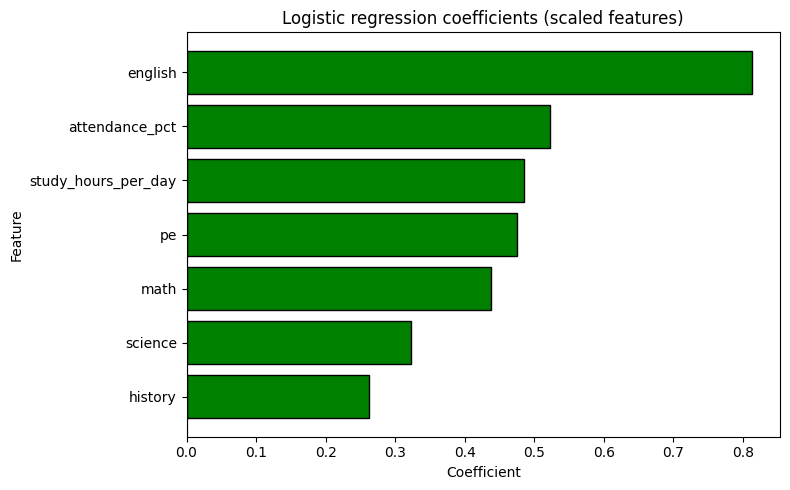


New student prediction: Pass
P(Fail)=0.0920, P(Pass)=0.9080


d:\Masai\assignment-03-2511240\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Task 4 — Machine Learning
# Define feature columns (all predictors) and target variable (pass/fail outcome)
feature_cols = [
    "math",
    "science",
    "english",
    "history",
    "pe",
    "attendance_pct",
    "study_hours_per_day",
]
X = df[feature_cols]
y = df["passed"]

# Split data into 80% training and 20% testing with random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features using StandardScaler (mean=0, std=1) to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Evaluate model on training and test sets
train_acc = model.score(X_train_scaled, y_train)
print("Training accuracy:", train_acc)

y_pred = model.predict(X_test_scaled)
test_acc = model.score(X_test_scaled, y_test)
print("Test accuracy:", test_acc)
print()

# Display individual predictions vs actual values for test set
test_names = df.loc[X_test.index, "name"]
for name, actual, pred in zip(test_names, y_test, y_pred):
    ok = actual == pred
    mark = "✅ correct" if ok else "❌ wrong"
    print(f"{name}: actual={actual}, predicted={pred} — {mark}")

# Extract and sort coefficients to identify most important features
coefs = model.coef_[0]
pairs = sorted(zip(feature_cols, coefs), key=lambda t: abs(t[1]), reverse=True)
print()
print("Coefficients (sorted by |coef|):")
for name, c in pairs:
    print(f"  {name}: {c:.4f}")

# Visualize coefficients with horizontal bar chart (green=positive, red=negative)
plt.figure(figsize=(8, 5))
labels = [p[0] for p in pairs]
values = [p[1] for p in pairs]
colors = ["green" if v >= 0 else "red" for v in values]
plt.barh(labels[::-1], values[::-1], color=colors[::-1], edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic regression coefficients (scaled features)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot_coefs.png", dpi=150)
plt.show()

# Bonus — Make prediction for a new student with given scores and study habits
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled = scaler.transform(new_student)
pred_label = model.predict(new_scaled)[0]
proba = model.predict_proba(new_scaled)[0]
outcome = "Pass" if pred_label == 1 else "Fail"
print()
print("New student prediction:", outcome)
print(f"P(Fail)={proba[0]:.4f}, P(Pass)={proba[1]:.4f}")
